In [26]:
import argparse
import os
from os import path
import sys
import olefile
import numpy as np

from scipy.ndimage import percentile_filter
import scipy.ndimage

import sys

import h5writer
import h5py
import spts
import spts.camera
from spts.camera import CXDReader
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.patches
from matplotlib.colors import LogNorm
import random

In [27]:
def make_circle_mask(diameter):
    center = (diameter-1.) / 2.
    x,y = np.meshgrid(np.arange(diameter), np.arange(diameter))
    rsq = (x-center)**2 + (y-center)**2
    mask = rsq <= center**2
    return mask

In [29]:
background_cxd = "/home/tejvarmay/scattering_data/data/data02256.cxd"#"/home/lenaw/Data/50nmPS/data01741.cxd"#"/home/tejvarmay/scattering_data/data/data01712.cxd"

R = CXDReader(background_cxd)
N = R.get_number_of_frames()
frame = R.get_frame(0)
shape = (N, frame.shape[0], frame.shape[1])

BGR = np.zeros(shape)
for i in range(1,N): # Open frame by frame
 #   print("%s/100" %(i+1))
    frame = R.get_frame(i)

    BGR[i] = frame

BG = np.mean(BGR, axis=0)

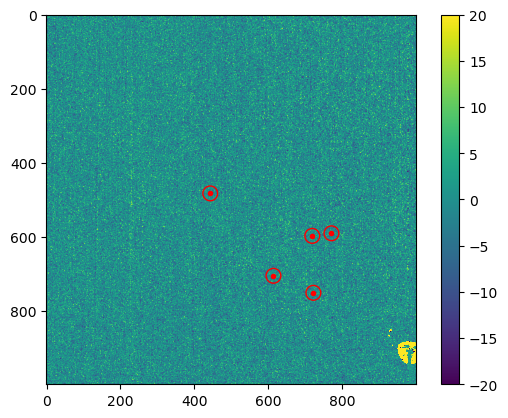

-35.370000000000026


In [30]:
framecorr=frame-BG
resizedframe = framecorr[0:1000,0:1000] # select only the upper left part where the particles typically are


fig, ax = plt.subplots()
plt.imshow(resizedframe, vmin = -20, vmax=20)

Intensity_array = []
for i in range(5):
    positionx, positiony = random.randint(400, 800), random.randint(400,800)    # generates a random position of background "particles" within the square 200-800 px. 
    plt.plot(positionx, positiony, ".r")                                        # plots the random centers 
    circle = plt.Circle((positionx, positiony), 20, color="red", fill=False)    # creates a circle with the center at the random position and the radius 10. 
    ax.add_patch(circle)                                                        # draws the previously defined circle
    
    #circle_mask = np.array()
    x = np.arange(positionx-5, positionx+5, 1)
    y = np.arange(positiony-5, positiony+5, 1)
    
    xx, yy = np.meshgrid(x, y)
    particle = resizedframe[xx,yy]*make_circle_mask(10)
    
    intensity = np.sum(particle)
    Intensity_array = np.append(Intensity_array, intensity)
    
plt.colorbar()
plt.show()

print(np.mean(Intensity_array))



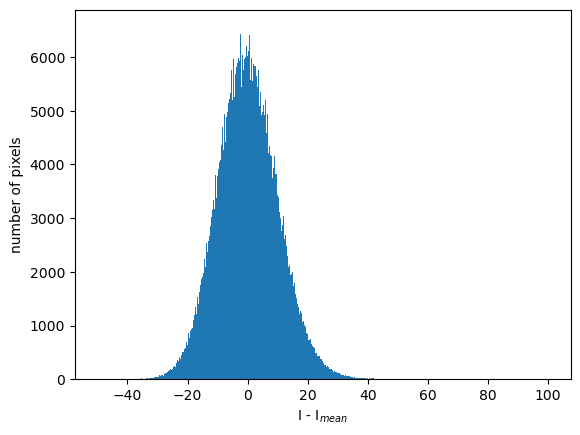

In [23]:
plt.figure()
plt.hist(resizedframe.ravel(), bins = 1000, range = (-50,100))
plt.ylabel("number of pixels")
plt.xlabel("I - I$_{mean}$")
#plt.axvline(x=20+1/(np.e**2), ymin=0, ymax=4000)
plt.show()



In [24]:
Cycle = 5

avg = []

particle_diameter = 44 

for n in range(Cycle):
    Intensity_array=[]
    for m in range(N):
        frame = R.get_frame(m)
        framecorr=frame-BG
        resizedframe = framecorr[0:1000,0:1000]
        for i in range(2):
            positionx, positiony = random.randint(400, 800), random.randint(400,800)    # generates a random position of background "particles" 

            x = np.arange(positionx-int(particle_diameter/2), positionx+int(particle_diameter/2), 1)
            y = np.arange(positiony-int(particle_diameter/2), positiony+int(particle_diameter/2), 1)


            
            xx, yy = np.meshgrid(x, y)
            particle = resizedframe[xx,yy]*make_circle_mask(particle_diameter)

            intensity = np.sum(particle)
            if intensity>0:
                Intensity_array = np.append(Intensity_array, intensity**(1/6))
                
    avg = np.append(avg, np.mean(Intensity_array))
            
print(np.round(np.mean(avg), 3), np.round(np.std(avg), 3))

3.452 0.012


In [25]:
avg

array([3.44895817, 3.46534436, 3.43330732, 3.46549018, 3.44896083])